# Modelo Analítico: Flujo 2D Viscoso con Transferencia de Calor y Placa Móvil

## 1. Hipótesis
- Flujo **incompresible** ($\nabla \cdot \mathbf{u} = 0$) y **laminar**.
- Dominio **bidimensional** (variaciones en $x$ y $y$).
- Placa inferior ($y = 0$) se mueve con velocidad $-U_p \hat{i}$ (sentido $-x$).
- Gradiente de presión constante en $x$: $\frac{\partial p}{\partial x} = \text{const.}$
- Efectos gravitacionales despreciables.

## 2. Ecuaciones Gobernantes

### Conservación de Momento (Navier-Stokes 2D)
**Componente $x$**:
$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

**Componente $y$**:
$$
\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)
$$

donde:
- $u$, $v$: Componentes de velocidad en $x$ e $y$.
- $\nu = \mu/\rho$: Viscosidad cinemática.

### Conservación de Energía
$$
\frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) + \frac{\Phi}{\rho c_p}
$$

**Disipación viscosa ($\Phi$)**:
$$
\Phi = \mu \left[ 2 \left( \frac{\partial u}{\partial x} \right)^2 + 2 \left( \frac{\partial v}{\partial y} \right)^2 + \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)^2 \right]
$$

### Esfuerzo Cortante ($\tau_{xy}$)
$$
\tau_{xy} = \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
$$

## 3. Condiciones de Frontera

| **Variable**   | **Placa Inferior ($y=0$)**       | **Superior ($y=H$)**       |
|----------------|----------------------------------|----------------------------|
| Velocidad $u$  | $u = -U_p$                       | $u = U_0$                  |
| Velocidad $v$  | $v = 0$ (no penetración)         | $v = 0$                    |
| Temperatura $T$| $T = T_0$                        | $T = T_1$                  |

## 4. Simplificaciones para Estado Estacionario
Si $\frac{\partial}{\partial t} = 0$ y $\frac{\partial p}{\partial x} = -\Delta p/L$:
$$
\nu \frac{d^2 u}{dy^2} = \frac{1}{\rho} \frac{\Delta p}{L}, \quad \text{con} \quad u(0) = -U_p, \quad u(H) = U_0
$$

**Solución analítica** para $u(y)$:
$$
u(y) = \frac{\Delta p}{2 \mu L} y (y - H) + \left(U_0 + U_p \frac{y}{H}\right) - U_p

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [17]:
# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 2.0, 1.0  # Dimensiones del dominio (x, y)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Propiedades del fluido
rho = 1.0            # Densidad
mu = 0.1             # Viscosidad dinámica
nu = mu / rho        # Viscosidad cinemática
alpha = 0.01         # Difusividad térmica
cp = 1.0             # Calor específico

# Condiciones de frontera
U_p = -1.0           # Velocidad de la placa (sentido contrario)
U_0 = 2.0            # Velocidad del flujo libre
T0, T1 = 0.0, 0.0    # Temperaturas de la placa y del fluido

# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Campos iniciales
u = np.zeros((ny, nx)) + U_0  # Velocidad horizontal
v = np.zeros((ny, nx))         # Velocidad vertical
T = np.zeros((ny, nx)) + T1    # Temperatura
p = np.zeros((ny, nx))         # Presión

# Aplicar condiciones de frontera
u[0, :] = U_p     # Placa inferior móvil
u[-1, :] = U_0    # Flujo libre superior
T[0, :] = T0      # Temperatura de la placa
T[-1, :] = T1     # Temperatura del fluido lejos de la 

# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u[i, j] = (u_old[i, j] + dt * (
                -u_old[i, j] * (u_old[i, j+1] - u_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (u_old[i+1, j] - u_old[i-1, j]) / (2*dy)
                + nu * (
                    (u_old[i, j+1] - 2*u_old[i, j] + u_old[i, j-1]) / dx**2
                    + (u_old[i+1, j] - 2*u_old[i, j] + u_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            T[i, j] = (T_old[i, j] + dt * (
                -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (T_old[i+1, j] - T_old[i-1, j]) / (2*dy)
                + alpha * (
                    (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
                    + (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
                )
                + (mu / (rho * cp)) * (  # Disipación viscosa (simplificada)
                    2 * ((u_old[i, j+1] - u_old[i, j-1]) / (2*dx))**2
                    + 2 * ((v_old[i+1, j] - v_old[i-1, j]) / (2*dy))**2
                    + ((u_old[i+1, j] - u_old[i-1, j]) / (2*dy) 
                      + (v_old[i, j+1] - v_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u[0, :] = U_p
    u[-1, :] = U_0
    v[:, 0] = v[:, -1] = 0
    T[0, :] = T0
    T[-1, :] = T1




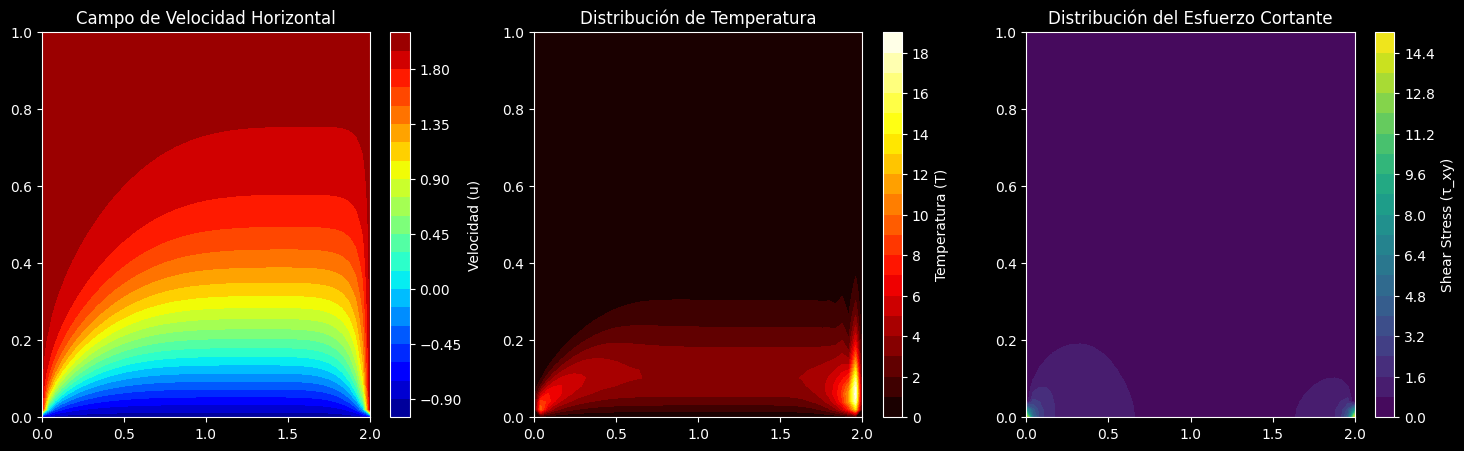

In [18]:
# REPRESENTACIÓN

# Gráfico de velocidad y temperatura
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u)')
plt.title('Campo de Velocidad Horizontal')

plt.subplot(1, 3, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T)')
plt.title('Distribución de Temperatura')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico del esfuerzo cortante
plt.subplot(1, 3, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Shear Stress (τ_xy)')
plt.title('Distribución del Esfuerzo Cortante')
plt.show()


---

## **Resultados Esperados**:
1. **Perfil de velocidad**: Transición entre la placa móvil $(-U_p)$ y el flujo libre $(U_0)$.
2. **Temperatura**: Gradiente térmico cerca de la placa caliente/fría.
3. **Shear stress**: Máximo cerca de la placa móvil debido a la alta deformación.

---

# Adimensionalización del Modelo de Flujo 2D con Transferencia de Calor

## 1. Adimensionalización de las Ecuaciones

### Variables Adimensionales
Definimos las siguientes variables normalizadas:

| Variable física | Variable adimensional | Escala de referencia |
|-----------------|-----------------------|-----------------------|
| $(x, y)$       | $(\tilde{x}, \tilde{y})$ | $L$ (longitud característica, ej. altura $H$) |
| $t$            | $\tilde{t}$           | $L/U_0$ (tiempo característico) |
| $(u, v)$       | $(\tilde{u}, \tilde{v})$ | $U_0$ (velocidad característica) |
| $p$            | $\tilde{p}$           | $\rho U_0^2$ (presión dinámica) |
| $T$            | $\tilde{T}$           | $\Delta T = T_1 - T_0$ |

### Parámetros Adimensionales Clave

1. **Número de Reynolds (Re)**:

   $$
   Re = \frac{\rho U_0 L}{\mu} = \frac{U_0 L}{\nu}
   $$

   - Relación entre fuerzas inerciales y viscosas.

2. **Número de Prandtl (Pr)**:

   $$
   Pr = \frac{\nu}{\alpha} = \frac{\mu c_p}{k}
   $$

   - Relación entre difusividad viscosa y térmica.

3. **Número de Eckert (Ec)**:

   $$
   Ec = \frac{U_0^2}{c_p \Delta T}
   $$
   
   - Importancia de disipación viscosa vs. transferencia de calor.

## 2. Ecuaciones Adimensionales

### Conservación de Masa
$$
\frac{\partial \tilde{u}}{\partial \tilde{x}} + \frac{\partial \tilde{v}}{\partial \tilde{y}} = 0
$$

### Conservación de Momento (Navier-Stokes)

**Componente $\tilde{x}$**:
$$
\frac{\partial \tilde{u}}{\partial \tilde{t}} + \tilde{u} \frac{\partial \tilde{u}}{\partial \tilde{x}} + \tilde{v} \frac{\partial \tilde{u}}{\partial \tilde{y}} = -\frac{\partial \tilde{p}}{\partial \tilde{x}} + \frac{1}{Re} \left( \frac{\partial^2 \tilde{u}}{\partial \tilde{x}^2} + \frac{\partial^2 \tilde{u}}{\partial \tilde{y}^2} \right)
$$
**Componente $\tilde{y}$**:
$$
\frac{\partial \tilde{v}}{\partial \tilde{t}} + \tilde{u} \frac{\partial \tilde{v}}{\partial \tilde{x}} + \tilde{v} \frac{\partial \tilde{v}}{\partial \tilde{y}} = -\frac{\partial \tilde{p}}{\partial \tilde{y}} + \frac{1}{Re} \left( \frac{\partial^2 \tilde{v}}{\partial \tilde{x}^2} + \frac{\partial^2 \tilde{v}}{\partial \tilde{y}^2} \right)
$$

### Conservación de Energía
$$
\frac{\partial \tilde{T}}{\partial \tilde{t}} + \tilde{u} \frac{\partial \tilde{T}}{\partial \tilde{x}} + \tilde{v} \frac{\partial \tilde{T}}{\partial \tilde{y}} = \frac{1}{Re Pr} \left( \frac{\partial^2 \tilde{T}}{\partial \tilde{x}^2} + \frac{\partial^2 \tilde{T}}{\partial \tilde{y}^2} \right) + \frac{Ec}{Re} \tilde{\Phi}
$$

**Disipación viscosa adimensional ($\tilde{\Phi}$)**:
$$
\tilde{\Phi} = 2 \left( \frac{\partial \tilde{u}}{\partial \tilde{x}} \right)^2 + 2 \left( \frac{\partial \tilde{v}}{\partial \tilde{y}} \right)^2 + \left( \frac{\partial \tilde{u}}{\partial \tilde{y}} + \frac{\partial \tilde{v}}{\partial \tilde{x}} \right)^2
$$

### Esfuerzo Cortante Adimensional
$$
\tilde{\tau}_{xy} = \frac{\partial \tilde{u}}{\partial \tilde{y}} + \frac{\partial \tilde{v}}{\partial \tilde{x}}
$$

## 3. Código en Python para la Simulación Adimensional

### Librerías necesarias

In [19]:
import numpy as np
import matplotlib.pyplot as plt

### **Parámetros Adimensionales**:

In [20]:
Re = 100.0       # Número de Reynolds
Pr = 0.7         # Número de Prandtl (aire ~ 0.7, agua ~ 7)
Ec = 0.1         # Número de Eckert (pequeño para flujos no muy rápidos)

# Geometría adimensional
Lx, Ly = 2.0, 1.0  # Dominio: x ∈ [0, 2], y ∈ [0, 1]
nx, ny = 50, 50     # Puntos de la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Tiempo adimensional
dt = 0.001          # Paso de tiempo
nt = 500            # Pasos de tiempo


### **Condiciones Iniciales y de Frontera**:


In [21]:

# Mallas
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Campos adimensionales
u = np.ones((ny, nx))        # Velocidad horizontal (inicialmente 1)
v = np.zeros((ny, nx))        # Velocidad vertical
T = np.zeros((ny, nx))        # Temperatura
p = np.zeros((ny, nx))        # Presión

# Condiciones de frontera
u[0, :] = -1.0    # Placa inferior móvil (ũ = -Up/U0)
u[-1, :] = 1.0     # Flujo libre superior (ũ = 1)
T[0, :] = 0.0      # Temperatura placa (T̃ = 0)
T[-1, :] = 1.0     # Temperatura fluido lejos (T̃ = 1)


### **Evolución Temporal (Esquema Explícito)**:

In [22]:
for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Navier-Stokes (componente u)
    u[1:-1, 1:-1] = (u_old[1:-1, 1:-1] + dt * (
        - u_old[1:-1, 1:-1] * (u_old[1:-1, 2:] - u_old[1:-1, :-2]) / (2*dx)
        - v_old[1:-1, 1:-1] * (u_old[2:, 1:-1] - u_old[:-2, 1:-1]) / (2*dy)
        + (1/Re) * (
            (u_old[1:-1, 2:] - 2*u_old[1:-1, 1:-1] + u_old[1:-1, :-2]) / dx**2
            + (u_old[2:, 1:-1] - 2*u_old[1:-1, 1:-1] + u_old[:-2, 1:-1]) / dy**2
        )
    ))

    # Energía (temperatura)
    T[1:-1, 1:-1] = (T_old[1:-1, 1:-1] + dt * (
        - u_old[1:-1, 1:-1] * (T_old[1:-1, 2:] - T_old[1:-1, :-2]) / (2*dx)
        - v_old[1:-1, 1:-1] * (T_old[2:, 1:-1] - T_old[:-2, 1:-1]) / (2*dy)
        + (1/(Re * Pr)) * (
            (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
            + (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
        )
        + (Ec / Re) * (  # Disipación viscosa
            2*((u_old[1:-1, 2:] - u_old[1:-1, :-2]) / (2*dx))**2
            + 2*((v_old[2:, 1:-1] - v_old[:-2, 1:-1]) / (2*dy))**2
            + ((u_old[2:, 1:-1] - u_old[:-2, 1:-1]) / (2*dy) 
              + (v_old[1:-1, 2:] - v_old[1:-1, :-2]) / (2*dx))**2
        )
    ))

    # Aplicar condiciones de frontera
    u[0, :] = -1.0
    u[-1, :] = 1.0
    v[:, 0] = v[:, -1] = 0
    T[0, :] = 0.0
    T[-1, :] = 1.0


### **Visualización**:

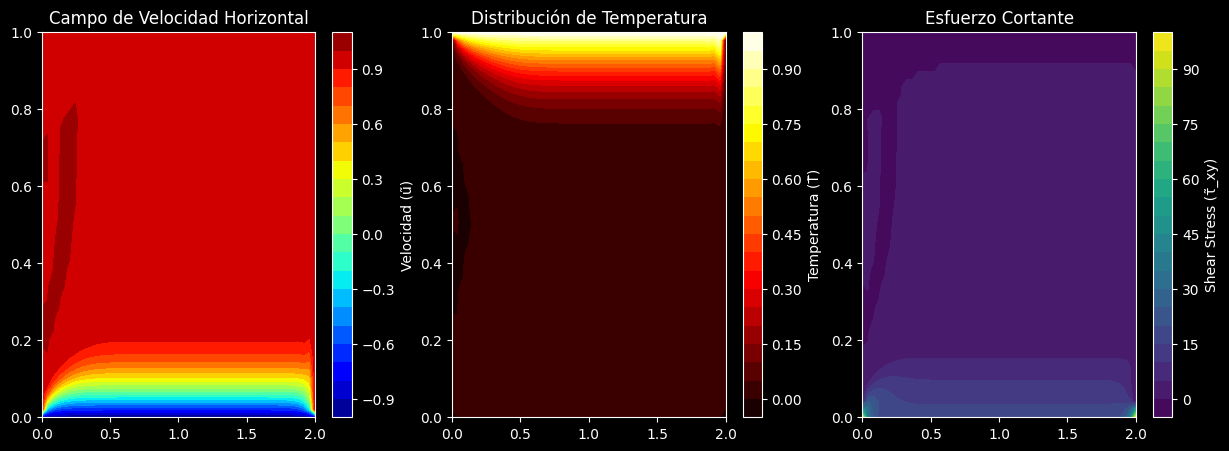

In [23]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (ũ)')
plt.title('Campo de Velocidad Horizontal')

plt.subplot(1, 3, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T̃)')
plt.title('Distribución de Temperatura')

# Shear stress adimensional
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = dudy + dvdx

plt.subplot(1, 3, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Shear Stress (τ̃_xy)')
plt.title('Esfuerzo Cortante')
plt.show()


---

## **Interpretación de Resultados**:
1. **Perfil de velocidad**: Transición entre (-1) (placa) y (1) (flujo libre), con efectos viscosos dominantes si (Re) es bajo.
2. **Temperatura**: Gradiente controlado por (Pr) y (Ec). Si (Ec ll 1), la disipación viscosa es despreciable.
3. **Shear stress**: Máximo cerca de la placa móvil, proporcional a (1/Re).

---
---

# Modelo Analítico de Flujo 2D Viscoso con Transferencia de Calor

## 1. Hipótesis
- Fluido **incompresible** ($\nabla \cdot \mathbf{u} = 0$)
- Dominio bidimensional ($x$, $y$)
- Placa inferior móvil ($u(y=0) = -U_p$)
- Gradiente de presión $\frac{\partial p}{\partial x}$ no constante
- Propiedades del fluido ($\rho$, $\mu$, $k$, $c_p$) constantes

## 2. Ecuaciones Gobernantes

### Conservación de Masa (Incompresibilidad)
$$
\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0
$$

### Conservación de Momento (Navier-Stokes)

**Componente $x$ (transitorio)**:
$$
\rho \left( \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} \right) = -\frac{\partial p}{\partial x} + \mu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

**Componente $y$ (transitorio)**:
$$
\rho \left( \frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} \right) = -\frac{\partial p}{\partial y} + \mu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)
$$

### Conservación de Energía (Transitorio)
$$
\rho c_p \left( \frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} \right) = k \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) + \Phi
$$

**Disipación viscosa ($\Phi$)**:
$$
\Phi = \mu \left[ 2\left(\frac{\partial u}{\partial x}\right)^2 + 2\left(\frac{\partial v}{\partial y}\right)^2 + \left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}\right)^2 \right]
$$

## 3. Condiciones de Frontera

### Velocidad
- **Placa inferior** ($y=0$):
  $$u = -U_p,\quad v = 0$$
- **Placa superior** ($y=H$):
  $$u = U_0,\quad v = 0$$
- **Paredes laterales** (condiciones periódicas o no deslizamiento)

### Temperatura
- **Placa inferior** ($y=0$):
  $$T = T_0$$
- **Placa superior** ($y=H$):
  $$T = T_1$$

## 4. Estado Estacionario ($\frac{\partial}{\partial t} = 0$)

### Ecuaciones Simplificadas

**Momento en $x$**:
$$
\rho \left( u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} \right) = -\frac{\partial p}{\partial x} + \mu \nabla^2 u
$$

**Energía**:
$$
\rho c_p \left( u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} \right) = k \nabla^2 T + \Phi
$$

## 5. Esquema Numérico (Diferencias Finitas)

### Discretización Temporal (Explícito)
$$
\frac{u^{n+1} - u^n}{\Delta t} = \text{RHS}^n
$$

### Discretización Espacial
- Derivadas primeras: **Diferencias centradas**
  $$\frac{\partial u}{\partial x} \approx \frac{u_{i+1,j} - u_{i-1,j}}{2\Delta x}$$
- Derivadas segundas: **Esquema de 5 puntos**
  $$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}$$

### **Descripción de la Solución Transitoria para el Modelo Laminar**

En el caso **transitorio**, las ecuaciones de momento y energía dependen del tiempo (\( t \)), lo que permite estudiar la evolución de:
1. **Velocidad \( u(y, t) \)** (componente \( x \), asumiendo \( v = 0 \) por simplificación).  
2. **Temperatura \( T(y, t) \)**.  
3. **Esfuerzo cortante \( \tau_{xy}(y, t) \)** (derivado de \( u(y, t) \)).

#### **Supuestos clave**:
- Flujo **incompresible** y **unidimensional** (solo variación en \( y \)).  
- Placa inferior (\( y = 0 \)) se mueve con \( u(0, t) = -U_p \), y la superior (\( y = H \)) con \( u(H, t) = U_0 \).  
- Temperatura fija en paredes: \( T(0, t) = T_0 \), \( T(H, t) = T_1 \).  
- Gradiente de presión constante: \( \frac{\partial p}{\partial x} = -\frac{\Delta p}{L} \).  
- Disipación viscosa incluida en la ecuación de energía.

---

### **Ecuaciones Transitorias Simplificadas**
1. **Momento en \( x \)**:
   $$
   \frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2} + \frac{1}{\rho} \frac{\Delta p}{L}
   $$

2. **Energía**:
   $$
   \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial y^2} + \frac{\nu}{c_p} \left( \frac{\partial u}{\partial y} \right)^2
   $$

3. **Esfuerzo cortante**:
   $$
   \tau_{xy}(y, t) = \mu \frac{\partial u}{\partial y}
   $$

---

### **Método Numérico: Diferencias Finitas (Explícito)**
Discretizamos en espacio (\( y \)) y tiempo (\( t \)):  
- \( y_j = j \Delta y \) (\( j = 0, \dots, N \)), \( \Delta y = H/N \).  
- \( t^n = n \Delta t \) (\( n = 0, \dots, M \)).  

#### **Esquemas de discretización**:
1. **Velocidad** (ecuación parabólica):
   $$
   \frac{u_j^{n+1} - u_j^n}{\Delta t} = \nu \frac{u_{j+1}^n - 2u_j^n + u_{j-1}^n}{\Delta y^2} + \frac{\Delta p}{\rho L}
   $$

2. **Temperatura**:
   $$
   \frac{T_j^{n+1} - T_j^n}{\Delta t} = \alpha \frac{T_{j+1}^n - 2T_j^n + T_{j-1}^n}{\Delta y^2} + \frac{\nu}{c_p} \left( \frac{u_{j+1}^n - u_{j-1}^n}{2 \Delta y} \right)^2
   $$

3. **Esfuerzo cortante** (centrado):
   $$
   \tau_{xy,j}^n = \mu \frac{u_{j+1}^n - u_{j-1}^n}{2 \Delta y}
   $$

#### **Estabilidad**:
- Requiere \( \Delta t \leq \frac{\Delta y^2}{2 \max(\nu, \alpha)} \) (condición CFL).

---

### **Código en Python (usando `numpy` y `matplotlib`)**



---

### **Resultados Esperados**:
1. **Velocidad**:  
   - Evoluciona desde el reposo hasta un perfil parabólico (si \( \Delta p \neq 0 \)) o lineal (si \( \Delta p = 0 \)).  
2. **Temperatura**:  
   - Aumenta cerca de la placa caliente (\( T_1 \)) y muestra gradientes influenciados por la disipación viscosa.  
3. **Esfuerzo cortante**:  
   - Máximo cerca de las paredes (gradientes de velocidad altos).  

### **Notas**:
- Para mayor precisión, se puede usar un esquema **implícito** (Crank-Nicolson).  
- La disipación viscosa (\( \Phi \)) es significativa si \( U_p \) o \( \Delta p \) son grandes.  
- El código puede adaptarse para incluir convección natural (efectos de flotabilidad).  

¿Necesitas ayuda para modificar algún parámetro o añadir más física al modelo?